# Heart Disease UCI Prediction Using Logistic Regresion

| Column       | Meaning                 |
| ------------ | ----------------------- |
| age          | Age of patient          |
| sex          | Gender                  |
| cp           | Chest pain type         |
| trestbps     | Resting blood pressure  |
| chol         | Cholesterol             |
| fbs          | Fasting blood sugar     |
| restecg      | ECG results             |
| thalach      | Maximum heart rate      |
| exang        | Exercise-induced angina |
| oldpeak      | ST depression           |
| slope        | Slope of ST segment     |
| ca           | Number of major vessels |
| thal         | Thalassemia             |
| num / target  | Heart disease diagnosis |


In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt

In [2]:

df = pd.read_csv('./heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [7]:
# Basic inpections
print("Basic inspection results")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")

print("First 5 rows")
print(df.head())

print("\nSummary statistic")
print(df.describe().round(2))

Basic inspection results
Shape : (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
First 5 rows
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Summary statistic
           age      sex       cp  trestbps     chol      fbs  restecg  \
count  1025.00  1025.00  1025.00   1025.00  1025.00  1025.00  1025.00   
mean     54.43     0.70    

In [8]:
# Missing Values
print("Missing Values")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'count':missing,
    'percentage':missing_pct
})
print(missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False))

Missing Values
Empty DataFrame
Columns: [count, percentage]
Index: []


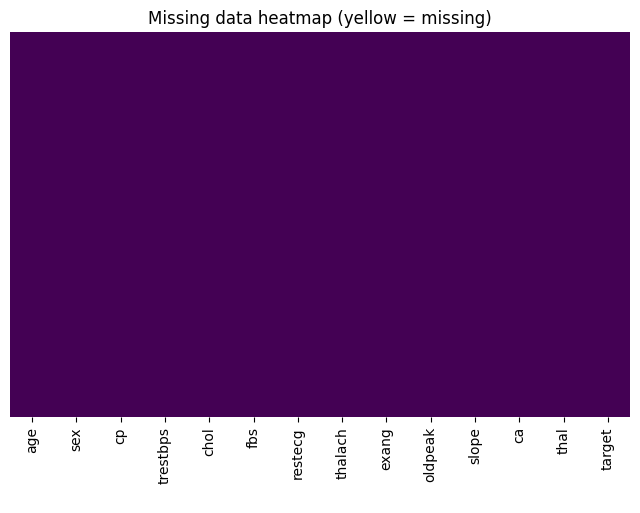

In [9]:
# plot missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis',yticklabels=False)
plt.title("Missing data heatmap (yellow = missing)")
plt.xlabel(" ")
plt.ylabel("")
plt.show()

In [35]:
# 4. Target Distribution
TARGET = "target"
print("Target Distribution")
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True).round(3))

Target Distribution
target
1    526
0    499
Name: count, dtype: int64
target
1    0.513
0    0.487
Name: proportion, dtype: float64


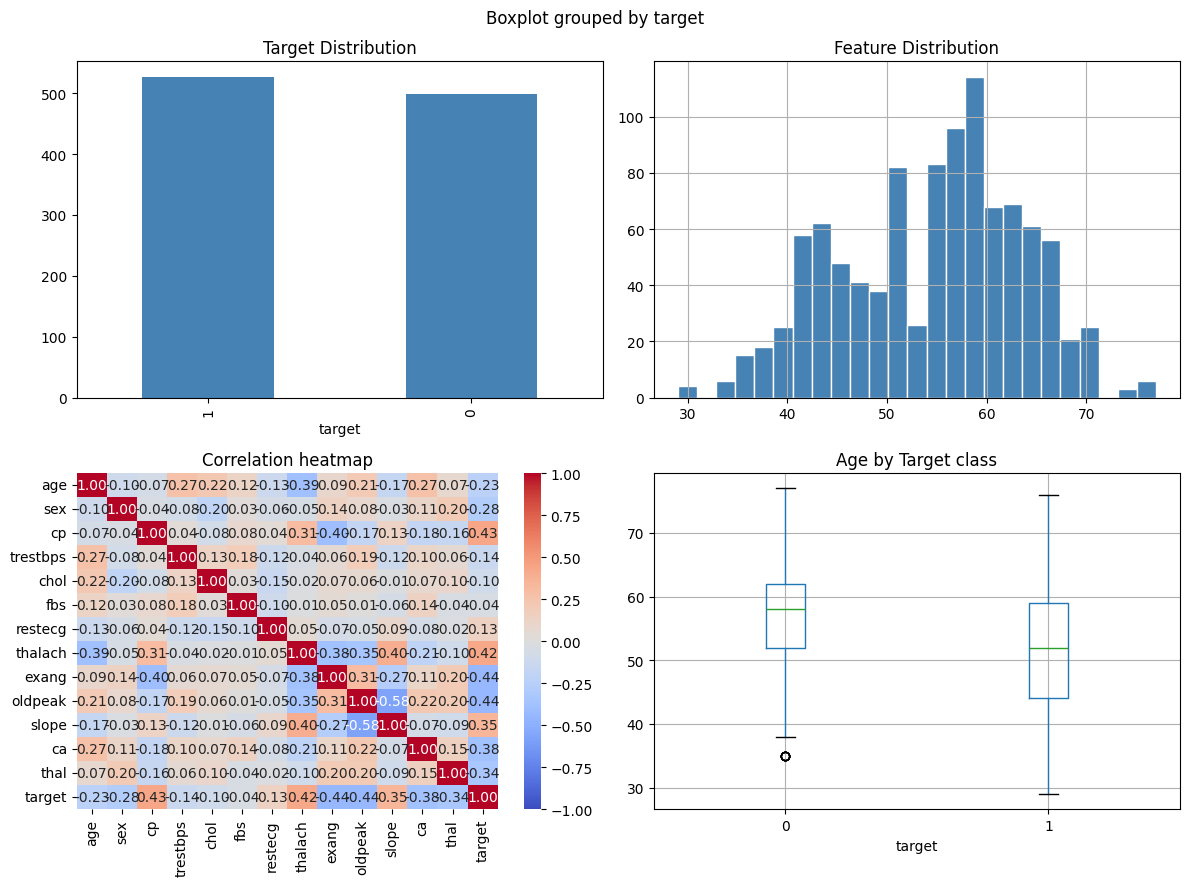

In [36]:
# 5. Visualization
fig, axes = plt.subplots(2,2, figsize=(12,9))

# target distribution
df[TARGET].value_counts().plot(kind='bar',ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Target Distribution")

# feature disbribution
df['age'].hist(ax=axes[0,1], bins=25, color='steelblue', edgecolor='white')
axes[0,1].set_title("Feature Distribution")

# correlation headmap (numerical column)
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,0], vmin=-1,vmax=1)
axes[1,0].set_title("Correlation heatmap")

# Feature vs target (age v target)
df.boxplot(column='age', by=TARGET, ax=axes[1,1])
axes[1,1].set_title('Age by Target class')

plt.tight_layout()
plt.show()

## EDA Findings
1. How many rows and columns?
   - 1043 rows
   - 14 colmums
3. Which columns have missing data and how much?
   - no missing data
5. Is the target class balanced or imbalanced?
   - target class is balanced (51/49)
7. Which features appear most correlate with the target?
   - cp -> chest pain
   - thalach -> maximum heart rate
9. Are there any obvious outliers to address?
    - three people with age 77
    - four people with age 29
11. Which columns are you going to DROP and WHY?
    - No

In [12]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [37]:
# 1. select and clean columns
df_clean = df.copy()

In [38]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [39]:
# Separating features from target
X = df_clean.drop(columns=TARGET)
y = df_clean[TARGET]

In [40]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 104.2 KB


In [41]:
y.info()

<class 'pandas.Series'>
RangeIndex: 1025 entries, 0 to 1024
Series name: target
Non-Null Count  Dtype
--------------  -----
1025 non-null   int64
dtypes: int64(1)
memory usage: 8.1 KB


In [19]:
print(f"Features remaining: {list[X.columns]}")
print(f"Shape: {X.shape}")
print(f"The Target : {TARGET}")

Features remaining: list[Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')]
Shape: (1025, 13)
The Target : target


In [20]:
# splitting then preprocessing
# stratiy ensure that your training and test
# sets maintain the same class proportion as the original dataset
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=42,
                                                   stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (820, 13) | Test: (205, 13)


In [21]:
# Identify column types
num_cols = ["age","trestbps","chol","thalach","oldpeak"]
cat_cols = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]

print(f"Numerical: {num_cols}")
print(f"Categorical: {cat_cols}")

Numerical: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [22]:
# Building the pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder' , OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num',num_pipeline, num_cols),
    ('cat',cat_pipeline,cat_cols)
])

X_tr_transformed = preprocessor.fit_transform(X_train)
print(f'After preprocessing X trainded: {X_tr_transformed.shape}')

After preprocessing X trainded: (820, 22)


In [23]:
# full pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [24]:
# train 
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [25]:
# predict
y_pred = pipeline.predict(X_test)

In [26]:
# accuracy 
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 87.32%


In [33]:
# classificaton report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.84      0.87       100
           1       0.86      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



In [34]:
# cross validation

scores = cross_val_score(pipeline, X, y, cv=5)

scores = np.array(scores)

# Summary stats
mean_score = scores.mean()
min_score = scores.min()
max_score = scores.max()

print("Cross-Validation Results (5-Fold)\n")
print("Fold Accuracies:")
for i, score in enumerate(scores, 1):
    print(f"Fold {i}: {score:.3%}")

print("\nSummary:")
print(f"Mean Accuracy : {mean_score:.3%}")
print(f"Min Accuracy  : {min_score:.3%}")
print(f"Max Accuracy  : {max_score:.3%}")

print("\nFinal Result:")
print(f"Cross-validation Accuracy: {scores.mean():.3%}")

Cross-Validation Results (5-Fold)

Fold Accuracies:
Fold 1: 87.317%
Fold 2: 86.341%
Fold 3: 90.244%
Fold 4: 85.366%
Fold 5: 81.463%

Summary:
Mean Accuracy : 86.146%
Min Accuracy  : 81.463%
Max Accuracy  : 90.244%

Final Result:
Cross-validation Accuracy: 86.146%


In [42]:
# roc-auc
from sklearn.metrics import roc_auc_score

probs = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, probs)

print(roc_auc)

0.9436190476190477


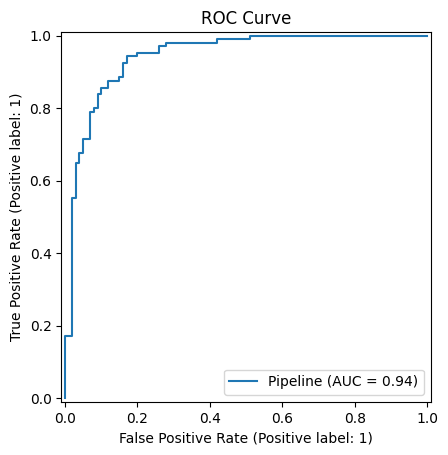

In [43]:
# plot 
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Plot ROC Curve
RocCurveDisplay.from_estimator(
    pipeline,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()